#### prever se as pessoas vao ter um ataque cardiaco do data set da pasta Heart_attack com random forest

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

# load the dataset
df = pd.read_csv(r'../dataset/Heart_Attack/Heart_Attack.csv')

df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,Male,atypical angina,130.0,132.0,False,2.0,185.0,no,0.0,NaN,NaN,NaN,0
1,29,Male,atypical angina,120.0,243.0,False,0.0,160.0,no,0.0,NaN,NaN,NaN,0
2,29,Male,atypical angina,140.0,NaN,False,0.0,170.0,no,0.0,NaN,NaN,NaN,0
3,30,Female,typical angina,170.0,237.0,False,1.0,170.0,no,0.0,NaN,NaN,fixed defect,0
4,31,Female,atypical angina,100.0,219.0,False,1.0,150.0,no,0.0,NaN,NaN,NaN,0
5,32,Female,atypical angina,105.0,198.0,False,0.0,165.0,no,0.0,NaN,NaN,NaN,0
6,32,Male,atypical angina,110.0,225.0,False,0.0,184.0,no,0.0,NaN,NaN,NaN,0
7,32,Male,atypical angina,125.0,254.0,False,0.0,155.0,no,0.0,NaN,NaN,NaN,0
8,33,Male,non-anginal pain,120.0,298.0,False,0.0,185.0,no,0.0,NaN,NaN,NaN,0
9,34,Female,atypical angina,130.0,161.0,False,0.0,190.0,no,0.0,NaN,NaN,NaN,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    int64  
 1   sex       294 non-null    object 
 2   cp        294 non-null    object 
 3   trestbps  293 non-null    float64
 4   chol      271 non-null    float64
 5   fbs       286 non-null    object 
 6   restecg   293 non-null    float64
 7   thalach   293 non-null    float64
 8   exang     293 non-null    object 
 9   oldpeak   294 non-null    float64
 10  slope     104 non-null    object 
 11  ca        3 non-null      float64
 12  thal      28 non-null     object 
 13  num       294 non-null    int64  
dtypes: float64(6), int64(2), object(6)
memory usage: 32.3+ KB


In [3]:
df.describe()

,age,trestbps,chol,restecg,thalach,oldpeak,ca,num
count,294.000000,293.000000,271.000000,293.000000,293.000000,294.000000,3.0,294.000000
mean,47.826531,132.583618,250.848708,0.218430,139.129693,0.586054,0.0,0.360544
std,7.811812,17.626568,67.657711,0.460868,23.589749,0.908648,0.0,0.480977
min,28.000000,92.000000,85.000000,0.000000,82.000000,0.000000,0.0,0.000000
25%,42.000000,120.000000,209.000000,0.000000,122.000000,0.000000,0.0,0.000000
50%,49.000000,130.000000,243.000000,0.000000,140.000000,0.000000,0.0,0.000000
75%,54.000000,140.000000,282.500000,0.000000,155.000000,1.000000,0.0,1.000000
max,66.000000,200.000000,603.000000,2.000000,190.000000,5.000000,0.0,1.000000


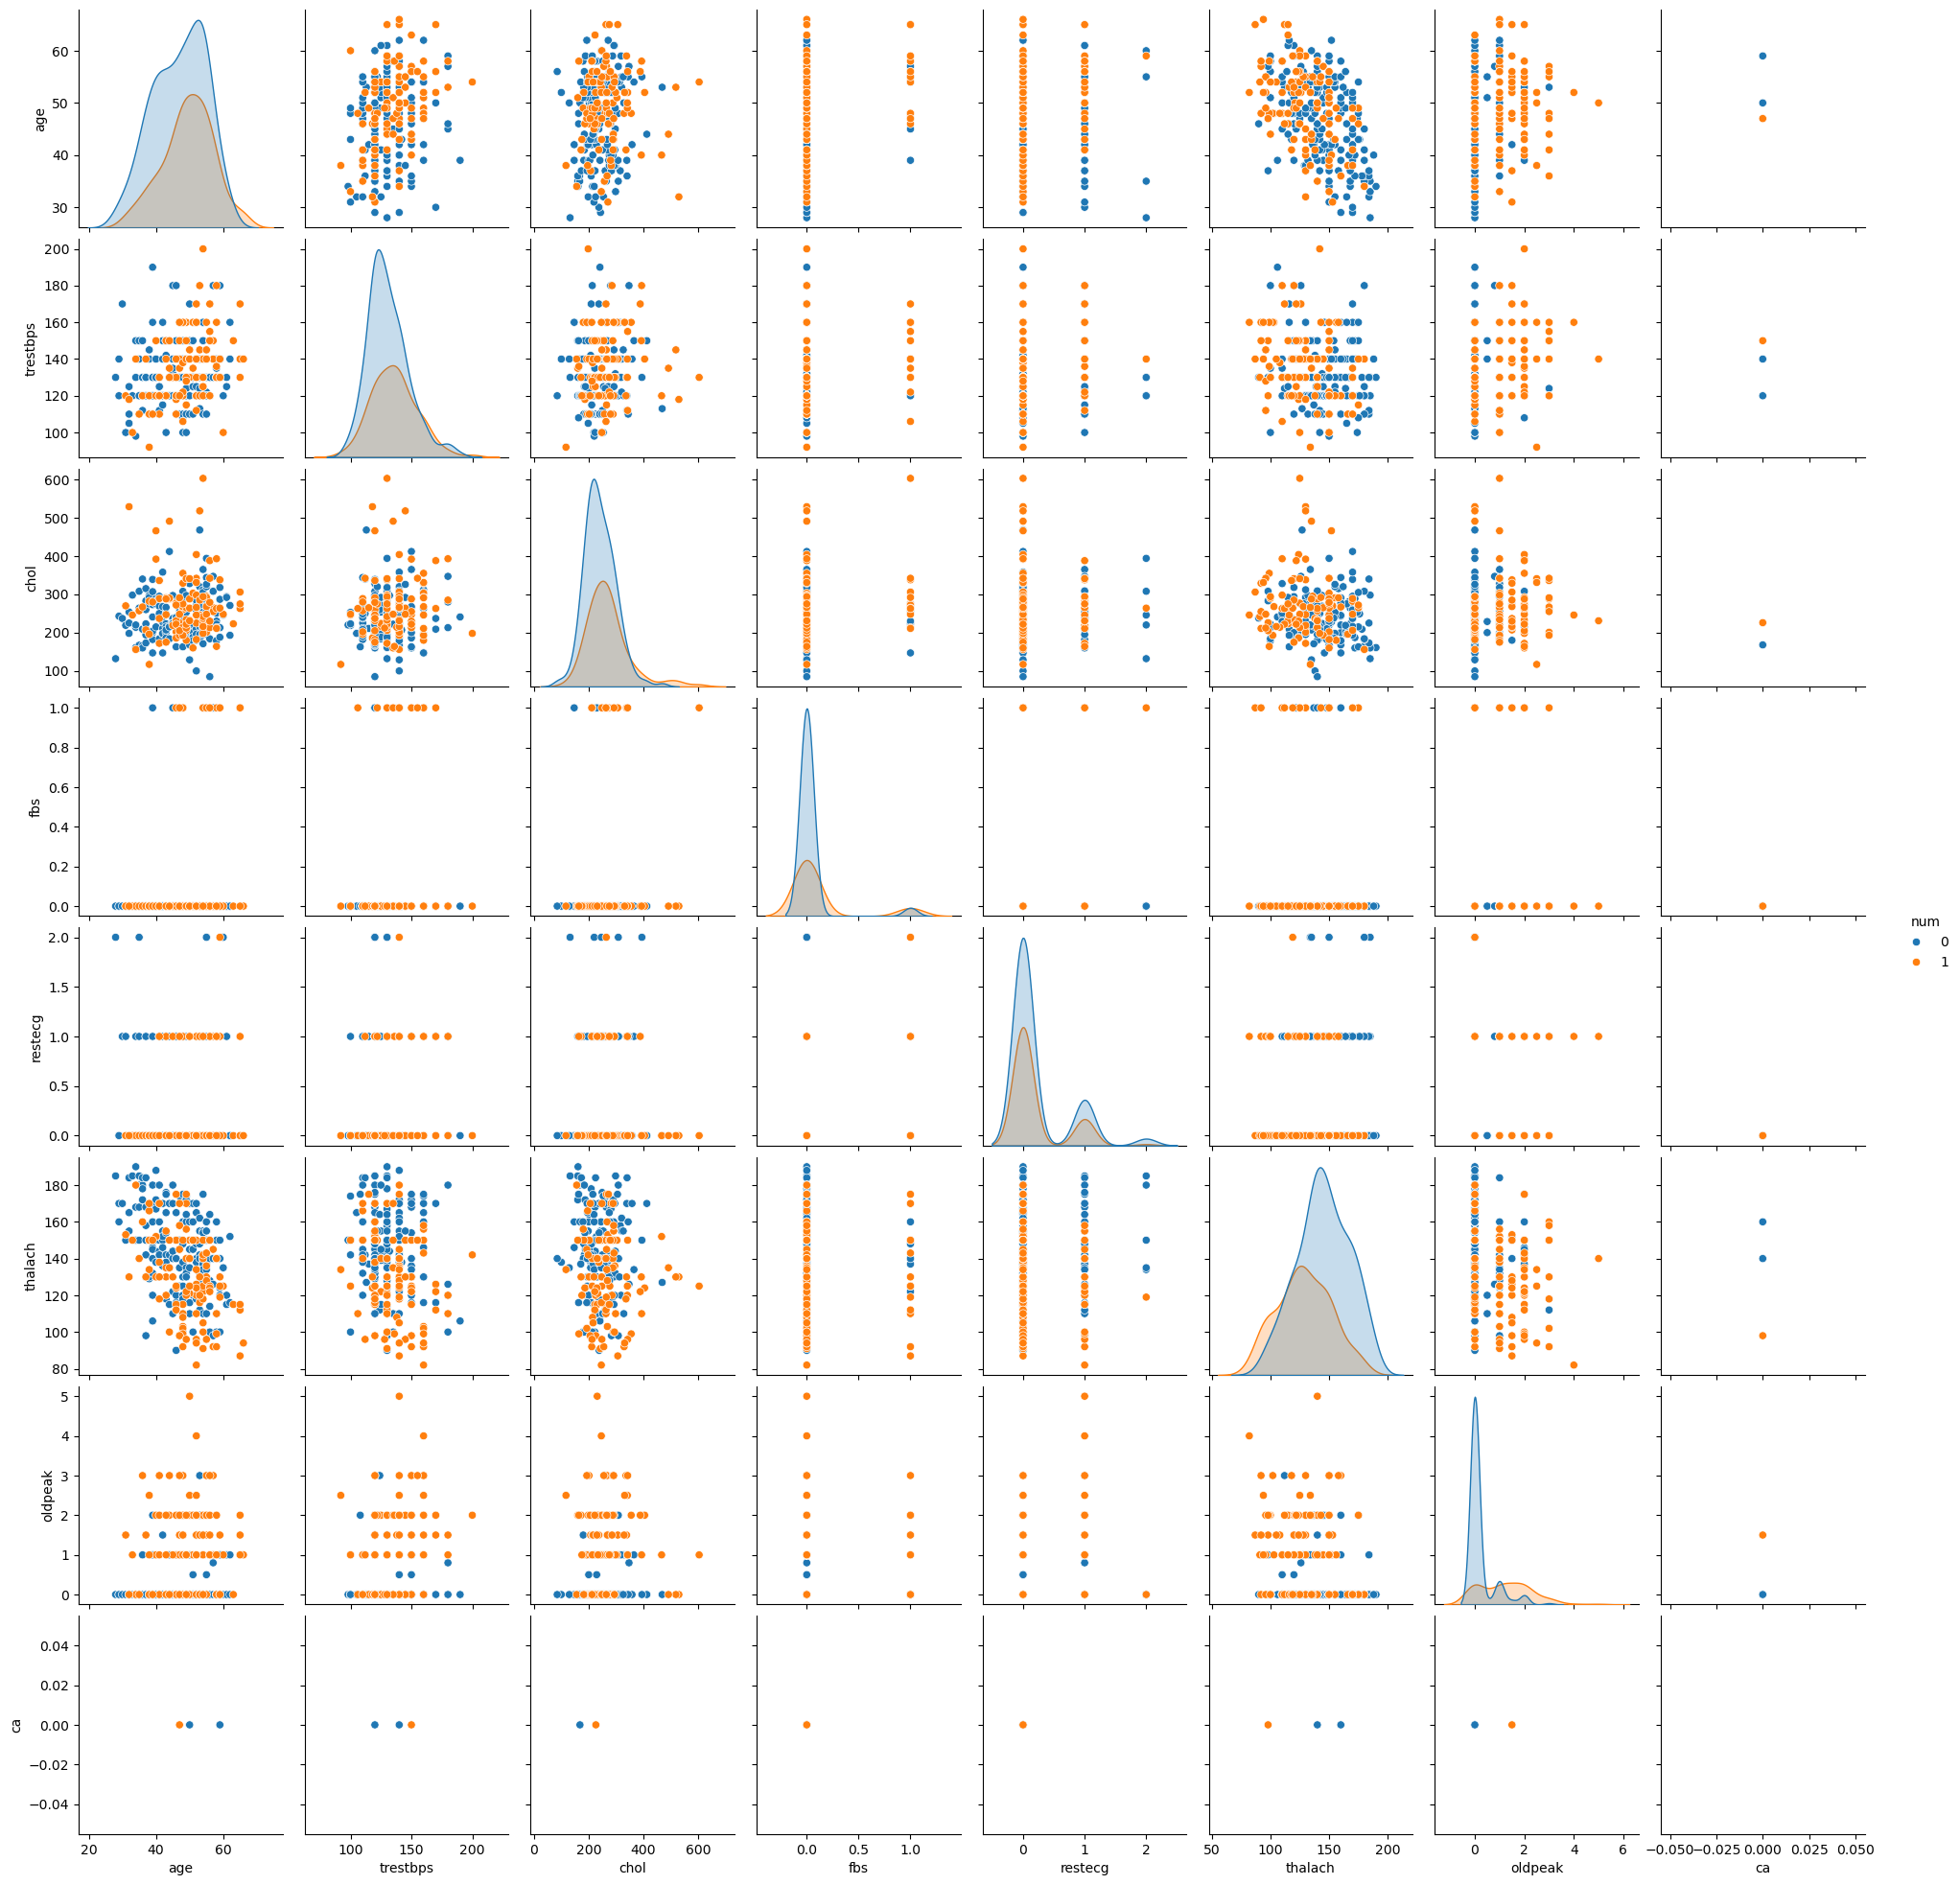

In [5]:
sns.pairplot(df, hue='num')

In [6]:
df.isnull().sum()

age           0
sex           0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalach       1
exang         1
oldpeak       0
slope       190
ca          291
thal        266
num           0
dtype: int64

In [9]:
for col in df.columns:
    print(col + ': ' + str((df[col] == 0).sum()))

age: 0
sex: 0
cp: 0
trestbps: 0
chol: 0
fbs: 266
restecg: 235
thalach: 0
exang: 0
oldpeak: 189
slope: 0
ca: 3
thal: 0
num: 188


In [ ]:
df['trestbps'] = df['trestbps'].replace(np.nan, df['trestbps'].median())
df['chol'] = df['chol'].replace(np.nan, df['chol'].median())
df['fbs'] = df['fbs'].map({'TRUE':1,'FALSE':0})
m = df['fbs'].mode()
df['fbs'] = df['fbs'].fillna(m.iloc[0] if not m.empty else 0)
df['restecg'] = df['restecg'].replace(np.nan, df['restecg'].median())
df['thalach'] = df['thalach'].replace(np.nan, df['thalach'].median())
df['exang'] = df['exang'].map({"yes": 1, "no": 0})
df['exang'] = df['exang'].fillna(df['exang'].mode().iloc[0])
df['slope'] = df['slope'].map({"upsloping": 1, "flat": 2, "downsloping": 3})
df['slope'] = df['slope'].replace(np.nan, 1)
df['ca'] = df['ca'].replace(np.nan, -1) 
df['thal'] = df['thal'].map({"normal": 1, "reversible": 2, "fixed": 3})
df['thal'] = df['thal'].replace(np.nan, 1)

In [13]:
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,Male,atypical angina,130.0,132.0,0.0,2.0,185.0,0.0,0.0,1.0,-1.0,1.0,0
1,29,Male,atypical angina,120.0,243.0,0.0,0.0,160.0,0.0,0.0,1.0,-1.0,1.0,0
2,29,Male,atypical angina,140.0,243.0,0.0,0.0,170.0,0.0,0.0,1.0,-1.0,1.0,0
3,30,Female,typical angina,170.0,237.0,0.0,1.0,170.0,0.0,0.0,1.0,-1.0,1.0,0
4,31,Female,atypical angina,100.0,219.0,0.0,1.0,150.0,0.0,0.0,1.0,-1.0,1.0,0
5,32,Female,atypical angina,105.0,198.0,0.0,0.0,165.0,0.0,0.0,1.0,-1.0,1.0,0
6,32,Male,atypical angina,110.0,225.0,0.0,0.0,184.0,0.0,0.0,1.0,-1.0,1.0,0
7,32,Male,atypical angina,125.0,254.0,0.0,0.0,155.0,0.0,0.0,1.0,-1.0,1.0,0
8,33,Male,non-anginal pain,120.0,298.0,0.0,0.0,185.0,0.0,0.0,1.0,-1.0,1.0,0
9,34,Female,atypical angina,130.0,161.0,0.0,0.0,190.0,0.0,0.0,1.0,-1.0,1.0,0
